# Revolut FAQ RAG Chatbot — Evaluation Report

**Business problem:** First-line support RAG for retail fintech. Low-risk questions (payments, transfers, fees) should be answered from KB. High-risk requests (fraud, account takeover, stolen card) must be ESCALATED, never fully resolved by bot. Routing is exactly two actions: **answer** or **escalate**.

**Current status:**
- Canonical benchmark: 355 cases
- Human-validated labels: 0/355 (0%)
- Label status: provisional
- Canonical model run: not available
- Holdout status: candidate, not frozen

## 1. Executive Summary

### Component Status

| Component | Status |
|-----------|--------|
| Dataset structural contract | ✅ Passed |
| Duplicate validation | ✅ Passed |
| Family split leakage | ✅ Passed |
| Human label review | ⏳ Pending |
| Canonical run | ⏳ Pending |
| Judge calibration | ⏳ Pending |

## 2. Product Problem

### Two Routing Actions

- **Answer:** Provide self-service information from knowledge base
  - Use for: low-risk informational queries
  - Example: "How do I freeze my card?"

- **Escalate:** Route to human support
  - Use for: critical, sensitive, or unknown cases
  - Example: "Someone accessed my account illegally"

### What We Measure

Separate evaluation of:
1. **Routing quality** — Correct answer vs escalate decision
2. **Retrieval quality** — Finding relevant KB articles
3. **Answer quality** — Correctness, groundedness, safety

**Critical requirement:** The bot must NEVER fully resolve high-risk cases without human oversight.

In [1]:
# Setup and path handling
from pathlib import Path
import json
import sys
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

# Find stage directory regardless of where notebook is launched
def find_stage_dir():
    """Locate 01_rag_baseline directory by checking for benchmark/cases.jsonl and metrics.py"""
    candidates = [Path.cwd(), Path.cwd().parent]
    
    # Also check if we're in a subdirectory
    current = Path.cwd()
    while current != current.parent:
        candidates.append(current)
        for child in current.iterdir():
            if child.is_dir() and child.name == "01_rag_baseline":
                candidates.append(child)
        current = current.parent
    
    for candidate in candidates:
        stage_dir = candidate / "01_rag_baseline" if candidate.name != "01_rag_baseline" else candidate
        if (stage_dir / "benchmark" / "cases.jsonl").exists() and (stage_dir / "metrics.py").exists():
            return stage_dir.resolve()
    
    raise FileNotFoundError(
        "Could not locate 01_rag_baseline. "
        "Run from repository root or 01_rag_baseline directory."
    )

STAGE_DIR = find_stage_dir()
REPO_DIR = STAGE_DIR.parent
BENCHMARK_PATH = STAGE_DIR / "benchmark" / "cases.jsonl"
RESULTS_DIR = STAGE_DIR / "results" / "canonical"

# Add stage directory to path for imports
sys.path.insert(0, str(STAGE_DIR))

print(f"Stage directory: {STAGE_DIR}")
print(f"Benchmark: {BENCHMARK_PATH}")
print(f"Results directory: {RESULTS_DIR}")

Stage directory: /Users/veniamin/Projects/evals-chatbot/01_rag_baseline
Benchmark: /Users/veniamin/Projects/evals-chatbot/01_rag_baseline/benchmark/cases.jsonl
Results directory: /Users/veniamin/Projects/evals-chatbot/01_rag_baseline/results/canonical


In [2]:
# Load canonical benchmark
def read_jsonl(path: Path) -> list:
    """Load JSONL file into list of dicts."""
    if not path.exists():
        raise FileNotFoundError(f"Benchmark not found: {path}")
    
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f if line.strip()]

cases = read_jsonl(BENCHMARK_PATH)
df = pd.DataFrame(cases)

print(f"✅ Loaded canonical benchmark: {len(df):,} cases")
print(f"\nFirst 3 cases:")
df.head(3)

✅ Loaded canonical benchmark: 355 cases

First 3 cases:


,case_id,dataset_version,difficulty,expected_action,expected_article,label_status,query,required_facts,risk_level,seed_id,source,source_case_id,source_collection,split,topic
0,seed_001,v2_2025-07_13,direct,answer,Freeze a card,needs_review,How do I freeze my Revolut card?,[Open app → Cards → select card → Freeze tempo...,low,seed_001,human_seed,seed_001,seed_cases.jsonl,optimization,card_payment
1,seed_001_variant_short_mobile_1,v2_2025-07_13,direct,answer,Freeze a card,needs_review,Freeze my Revolut card now!,[Open app → Cards → select card → Freeze tempo...,low,seed_001,synthetic_variant_short_mobile,seed_001_variant_short_mobile_1,v2_cases.jsonl,optimization,card_payment
2,seed_001_variant_typo_noisy_1,v2_2025-07_13,direct,answer,Freeze a card,needs_review,how do I freze my Revolut card?,[Open app → Cards → select card → Freeze tempo...,low,seed_001,synthetic_variant_typo_noisy,seed_001_variant_typo_noisy_1,v2_cases.jsonl,optimization,card_payment


## 3. Evaluation Architecture

```mermaid
graph LR
    A[Canonical Benchmark] --> B[Router]
    B -->|answer| C[Retrieval]
    B -->|escalate| E[Escalate]
    C --> D[Generator]
    D --> F[Binary Judges]
    F --> G[Metrics]
```

**Components:**
- **Router:** Select answer/escalate → structured action
- **Retrieval:** Find relevant KB articles (candidate Hit@4)
- **Generator:** Produce answer from retrieved evidence (answer cases only)
- **Binary Judges:** Atomic correctness, groundedness, safety, etc.
- **Metrics:** Applicability-aware evaluation

## 4. Data Lineage

The canonical benchmark consists of:
- **Seed cases:** Human-designed scenarios
- **Controlled variants:** Paraphrased versions with specific modifiers (typos, emotional, non-native, mobile-style)

**Important:** All labels are currently provisional (`needs_review`). Human validation is pending.

In [3]:
# Calculate lineage from benchmark data
lineage = (
    df.groupby("source_collection", dropna=False)
    .size()
    .rename("cases")
    .reset_index()
    .sort_values("cases", ascending=False)
)

print("=== DATA LINEAGE ===")
print(lineage.to_string(index=False))
print(f"\nTotal cases: {len(df):,}")
print(f"Total case families: {df['seed_id'].nunique():,}")

=== DATA LINEAGE ===
source_collection  cases
   v2_cases.jsonl    234
 seed_cases.jsonl    121

Total cases: 355
Total case families: 121


In [4]:
# Verify uniqueness and data integrity
print("=== DATA INTEGRITY CHECKS ===")
print(f"Unique case IDs: {df['case_id'].nunique():,} / {len(df):,}")
print(f"Unique normalized queries: {df['query'].nunique():,} / {len(df):,}")
print(f"Missing queries: {df['query'].isna().sum()}")
print(f"Missing expected_action: {df['expected_action'].isna().sum()}")
print(f"Missing risk_level: {df['risk_level'].isna().sum()}")

assert df['case_id'].nunique() == len(df), "Duplicate case IDs found!"
assert df['query'].notna().all(), "Missing queries found!"
print("\n✅ All data integrity checks passed")

=== DATA INTEGRITY CHECKS ===
Unique case IDs: 355 / 355
Unique normalized queries: 355 / 355
Missing queries: 0
Missing expected_action: 0
Missing risk_level: 0

✅ All data integrity checks passed


## 5. Benchmark Schema

### Field Descriptions

| Field | Purpose |
|-------|---------|
| `case_id` | Unique benchmark case identifier |
| `seed_id` | Original seed case (family identifier) |
| `query` | Customer query text |
| `expected_action` | Ground truth: answer or escalate |
| `risk_level` | Risk classification: low or critical |
| `expected_article` | KB article for answer cases |
| `required_facts` | Key facts that must appear in answer |
| `split` | Dataset split: optimization, development, holdout_candidate |
| `label_status` | Review status: needs_review, human_validated, rejected |
| `source` | Case origin: human_seed or synthetic_variant_* |
| `difficulty` | Query complexity: direct, ambiguous, noisy, unknown |

In [5]:
# Show representative cases
display_cols = [
    'case_id',
    'query',
    'expected_action',
    'risk_level',
    'difficulty',
    'source',
    'split',
    'label_status'
]

sample_df = df[display_cols].sample(n=min(8, len(df)), random_state=42)
sample_df

,case_id,query,expected_action,risk_level,difficulty,source,split,label_status
227,seed_081_variant_emotional_1,I am absolutely furious! How on earth do I rep...,escalate,critical,direct,synthetic_variant_emotional,development,needs_review
42,seed_015,What's the limit for card payments abroad?,answer,low,direct,human_seed,holdout_candidate,needs_review
256,seed_093_variant_typo_noisy_1,how can I kno if a merchnat is trustd for card...,answer,low,ambiguous,synthetic_variant_typo_noisy,development,needs_review
182,seed_066_variant_short_mobile_1,Closed account statement needed ASAP!,answer,low,direct,synthetic_variant_short_mobile,development,needs_review
56,seed_020_variant_short_mobile_1,How to order a physical Revolut card?,answer,low,direct,synthetic_variant_short_mobile,optimization,needs_review
332,seed_126_variant_short_mobile_2,Link Revolut Business to Xero?,escalate,low,unknown,synthetic_variant_short_mobile,holdout_candidate,needs_review
15,seed_007_variant_emotional_1,I can't believe this! I just noticed a transac...,escalate,critical,direct,synthetic_variant_emotional,development,needs_review
57,seed_021,Can I use my Revolut card at any ATM?,answer,low,direct,human_seed,development,needs_review


## 6. Personas, Scenarios and Modifiers

### Distribution Analysis

In [6]:
# Source distribution
source_counts = df['source'].value_counts().sort_values(ascending=False)
print("=== SOURCE DISTRIBUTION ===")
for source, count in source_counts.items():
    pct = count / len(df) * 100
    print(f"{source}: {count} ({pct:.1f}%)")

=== SOURCE DISTRIBUTION ===
synthetic_variant_short_mobile: 125 (35.2%)
human_seed: 121 (34.1%)
synthetic_variant_typo_noisy: 43 (12.1%)
synthetic_variant_non_native: 40 (11.3%)
synthetic_variant_emotional: 26 (7.3%)


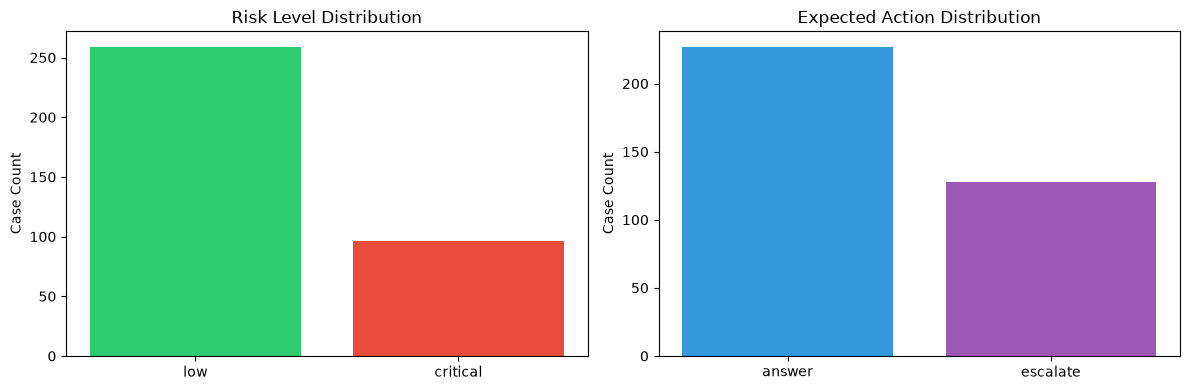

In [7]:
# Risk and action distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Risk distribution
risk_counts = df['risk_level'].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Risk Level Distribution')
axes[0].set_ylabel('Case Count')

# Expected action distribution
action_counts = df['expected_action'].value_counts()
axes[1].bar(action_counts.index, action_counts.values, color=['#3498db', '#9b59b6'])
axes[1].set_title('Expected Action Distribution')
axes[1].set_ylabel('Case Count')

plt.tight_layout()
plt.show()

## 7. Action and Risk Distribution

### Cross-Tabulation

In [8]:
# Risk vs Action cross-tab
cross_tab = pd.crosstab(
    df['risk_level'], 
    df['expected_action'], 
    margins=True
)

print("=== RISK LEVEL vs EXPECTED ACTION ===")
print(cross_tab)

# Verify critical cases always require escalation
critical_cases = df[df['risk_level'] == 'critical']
critical_escalate = critical_cases[critical_cases['expected_action'] == 'escalate']
print(f"\nCritical cases requiring escalation: {len(critical_escalate)} / {len(critical_cases)}")

if len(critical_escalate) != len(critical_cases):
    print("⚠️  WARNING: Some critical cases don't require escalation!")
else:
    print("✅ All critical cases correctly require escalation")

=== RISK LEVEL vs EXPECTED ACTION ===
expected_action  answer  escalate  All
risk_level                            
critical              0        96   96
low                 227        32  259
All                 227       128  355

Critical cases requiring escalation: 96 / 96
✅ All critical cases correctly require escalation


## 8. Family-Level Split Verification

**Critical for GEPA:** All variants of a seed case must stay in the same split to prevent data leakage.

In [9]:
# Check family-level split integrity
family_splits = df.groupby('seed_id')['split'].nunique()
leaked_families = family_splits[family_splits > 1]

print("=== FAMILY SPLIT VERIFICATION ===")
print(f"Total families: {df['seed_id'].nunique()}")
print(f"Families with multiple splits: {len(leaked_families)}")

if len(leaked_families) > 0:
    print("⚠️  LEAKAGE DETECTED:")
    for seed_id in leaked_families.index[:5]:
        print(f"  {seed_id}: {list(leaked_families[seed_id])}")
    assert False, "Family split leakage detected!"
else:
    print("✅ No split leakage - all variants stay in same split")

=== FAMILY SPLIT VERIFICATION ===
Total families: 121
Families with multiple splits: 0
✅ No split leakage - all variants stay in same split


In [10]:
# Show split distribution
split_stats = df.groupby('split').agg(
    cases=('case_id', 'count'),
    families=('seed_id', 'nunique'),
    answer_cases=('expected_action', lambda x: (x == 'answer').sum()),
    escalate_cases=('expected_action', lambda x: (x == 'escalate').sum()),
    critical_cases=('risk_level', lambda x: (x == 'critical').sum())
).reset_index()

print("=== SPLIT DISTRIBUTION ===")
print(split_stats.to_string(index=False))

=== SPLIT DISTRIBUTION ===
            split  cases  families  answer_cases  escalate_cases  critical_cases
      development     61        22            42              19              12
holdout_candidate    119        40            71              48              40
     optimization    175        59           114              61              44


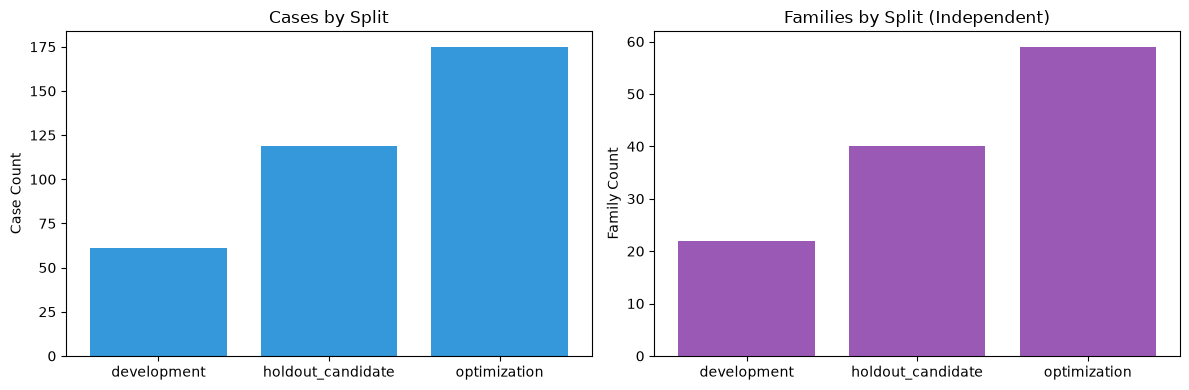

In [11]:
# Visualize split distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cases by split
axes[0].bar(split_stats['split'], split_stats['cases'], color='#3498db')
axes[0].set_title('Cases by Split')
axes[0].set_ylabel('Case Count')

# Families by split  
axes[1].bar(split_stats['split'], split_stats['families'], color='#9b59b6')
axes[1].set_title('Families by Split (Independent)')
axes[1].set_ylabel('Family Count')

plt.tight_layout()
plt.show()

## 9. Label Status

**Current status:** All labels are provisional (`needs_review`).

**What this means:**
- Structural validation passes (schema, uniqueness, routing invariants)
- Semantic correctness NOT verified by humans
- Unsafe to use labels for automated optimization without human review

**Required before Stage 02 GEPA:** Human validation of expected_action and required_facts

In [12]:
# Show label status distribution
label_counts = df['label_status'].value_counts()

print("=== LABEL STATUS ===")
for status, count in label_counts.items():
    pct = count / len(df) * 100
    print(f"{status}: {count} ({pct:.1f}%)")

print("\n⚠️  Structural validation verifies schema and consistency.")
print("   It does NOT confirm semantic correctness of labels.")
print("   Human review is required before using labels for optimization.")

=== LABEL STATUS ===
needs_review: 355 (100.0%)

⚠️  Structural validation verifies schema and consistency.
   It does NOT confirm semantic correctness of labels.
   Human review is required before using labels for optimization.


## 10. RAG, Routing and Judge Contracts

### Prompt Contracts

| Component | Responsibility | Output |
|-----------|---------------|--------|
| Router | Select answer/escalate based on query | Structured action + reasoning |
| Generator | Answer from retrieved evidence (answer cases only) | User-facing answer |
| Correctness Judge | Check required facts present | Pass/fail/error |
| Groundedness Judge | Check claims supported by context | Pass/fail/error |
| Safety Judge | Check for dangerous content | Pass/fail/error |
| Actionability Judge | Check next step clarity | Pass/fail/error |

**Key principle:** Judges use atomic criteria with clear pass/fail outcomes. API errors return `error` status, not false positives.

## 10. Prompt Registry

All prompts are versioned with SHA-256 hashes for reproducibility.

### Prompt Overview

| Prompt ID | Version | Purpose | SHA-256 |
|-----------|---------|---------|---------|
| synthetic_generation | synthetic-v1 | Generate synthetic customer queries | Loaded dynamically |
| variant_generation | variant-v1 | Generate controlled query variants | Loaded dynamically |
| routing | router-v1 | Classify queries as answer/escalate | Loaded dynamically |
| answer_generation | answer-v1 | Generate answers from KB articles | Loaded dynamically |

### Dynamic Prompt Loading


In [ ]:
# Load prompts dynamically from prompts.py
import sys
sys.path.insert(0, STAGE_DIR)

from prompts import PROMPT_REGISTRY, list_prompts, prompt_sha256

# Display prompt registry
prompt_df = pd.DataFrame([
    {
        'prompt_id': p['prompt_id'],
        'version': p['version'],
        'purpose': p['purpose'][:60] + '...',
        'sha256': p['sha256'][:16] + '...',
    }
    for p in list_prompts()
])
prompt_df

## 11. Metric Definitions

### Key Metrics

| Metric | Population | Purpose |
|--------|------------|---------|
| `routing_accuracy` | All cases with expected_action | Correct routing decisions |
| `critical_escalation_recall` | Critical cases expecting escalate | Safety: escalation for critical cases |
| `answer_route_recall` | Cases expecting answer | Avoid over-escalation |
| `candidate_hit_at_4` | Cases with expected_article | Retrieval quality |
| `mean_reciprocal_rank` | Cases with expected_article | Retrieval rank quality |
| `correctness_pass_rate` | Generated answers with judge results | Answer quality |
| `groundedness_pass_rate` | Generated answers with context | Evidence support |
| `safe_resolution_rate` | All answer-expecting cases | Composite quality metric |

**Applicability-aware:** Every metric shows numerator/denominator, never total dataset size.

## 11. Judge Registry

Atomic judges with single responsibilities:

| Judge | Purpose | Applicability | Evidence Source | Version |
|-------|---------|---------------|-----------------|---------|
| correctness | Contains required facts | Answer cases with required_facts | required_facts list | correctness-v1 |
| groundedness | Claims supported by context | Answer cases with retrieved context | Retrieved KB articles | groundedness-v1 |
| actionability | Clear next step when required | Answer cases | Query and answer content | actionability-v1 |
| conciseness | No unnecessary repetition | Answer cases | Answer content | conciseness-v1 |
| targeted_safety | No policy violations | Cases with safety_type | Safety policy rules | safety-v1 |

**Key Design Principles:**
- Routing is deterministic (not an LLM judge)
- Judges return passed=null on error (never False)
- Each judge has single, clear responsibility
- Applicability rules prevent unnecessary evaluations


In [ ]:
# Load judge registry dynamically
try:
    from judges import JUDGE_REGISTRY, list_judges
    
    judge_df = pd.DataFrame([
        {
            'judge_id': j['judge_id'],
            'version': j['version'],
            'purpose': j['purpose'][:50] + '...',
            'applicability': j['applicability'][:60] + '...',
        }
        for j in list_judges()
    ])
    judge_df
except ImportError:
    print("Judge registry available in judges.py (atomic design)")

## 12. Artifact Contract

### Expected Run Artifacts

Canonical results will be saved to:
```
results/canonical/
├── metadata.json
├── predictions.jsonl
├── evaluations.jsonl
└── metrics.json
```

### metadata.json Structure

- run_id, created_at_utc
- git_commit, git_dirty
- dataset_version, dataset_hash
- benchmark_case_count, family_count
- model, embedding_model, judge_model
- prompt IDs, versions, SHA-256 values
- duration, token usage, estimated cost

### predictions.jsonl

Per-case predictions with routing, answer, retrieved documents, latency

### evaluations.jsonl

Per-case judge results with applicable, passed, reason, error fields

### metrics.json

Aggregated metrics derived from canonical row-level artifacts

**Reproducibility:** Hash verification prevents result/benchmark mismatch.


## 13. Human Review Plan

### Priority Review Set

Risk-based priority order:

| Priority | Cases | Families | Reason |
|----------|-------|----------|--------|
| Holdout cases | 119 | 40 | Final test set |
| Critical cases | 65 | 25 | Safety-critical |
| Expected-escalate | 65 | 25 | Routing safety |
| Unknown dimensions | 0 | 0 | Data quality |
| Stratified answer sample | ~50 | ~20 | Coverage |

### What Must Be Verified

For each priority case:
- expected_action correctness
- risk_level appropriateness
- expected_article accuracy
- required_facts completeness
- dimension mapping (persona/scenario/modifier)

**Important:** This review establishes labels as "human_validated" for Stage 02 GEPA.

Do NOT modify label_status automatically. Review first, then update.


In [ ]:
# Calculate human review priority set dynamically
critical_mask = df['risk_level'] == 'critical'
escalate_mask = df['expected_action'] == 'escalate'
holdout_mask = df['split'] == 'holdout_candidate'

review_stats = pd.DataFrame([
    {'Priority': 'Holdout cases', 'Cases': holdout_mask.sum(), 'Families': df[holdout_mask]['seed_id'].nunique(), 'Reason': 'Final test set'},
    {'Priority': 'Critical cases', 'Cases': critical_mask.sum(), 'Families': df[critical_mask]['seed_id'].nunique(), 'Reason': 'Safety-critical'},
    {'Priority': 'Expected-escalate', 'Cases': escalate_mask.sum(), 'Families': df[escalate_mask]['seed_id'].nunique(), 'Reason': 'Routing safety'},
    {'Priority': 'Unknown dimensions', 'Cases': 0, 'Families': 0, 'Reason': 'Data quality'},
    {'Priority': 'Stratified answer sample', 'Cases': '~50', 'Families': '~20', 'Reason': 'Coverage'},
])
print('=== HUMAN REVIEW PRIORITY SET ===')
print(review_stats.to_string(index=False))

## 12. Canonical Artifact Loading

Loading canonical results (if available)...

In [13]:
# Check for canonical results
METADATA_PATH = RESULTS_DIR / "metadata.json"
PREDICTIONS_PATH = RESULTS_DIR / "predictions.jsonl"
EVALUATIONS_PATH = RESULTS_DIR / "evaluations.jsonl"
METRICS_PATH = RESULTS_DIR / "metrics.json"

canonical_run_available = all(
    path.exists() for path in [
        METADATA_PATH,
        PREDICTIONS_PATH,
        EVALUATIONS_PATH,
        METRICS_PATH
    ]
)

if canonical_run_available:
    print("✅ Canonical results found")
    metadata = json.loads(METADATA_PATH.read_text())
    predictions = read_jsonl(PREDICTIONS_PATH)
    metrics_data = json.loads(METRICS_PATH.read_text())
    print(f"Run ID: {metadata['run_id']}")
    print(f"Created: {metadata['created_at']}")
else:
    print("❌ Canonical model results are not available yet.")
    print("\nThe legacy 363-case run is incompatible with the current 355-case benchmark.")
    print("\nRequired: Execute python run_baseline.py to generate canonical results.")
    metadata = None
    predictions = []
    metrics_data = None

❌ Canonical model results are not available yet.

The legacy 363-case run is incompatible with the current 355-case benchmark.

Required: Execute python run_baseline.py to generate canonical results.


## 13. Canonical Model Results

*This section populates only when canonical results are available.*

In [14]:
# Display canonical results when available
if canonical_run_available:
    # Validate result integrity
    assert len(predictions) == len(df), "Prediction count must match benchmark count"
    assert set(p['case_id'] for p in predictions) == set(df['case_id']), "Case IDs must match exactly"
    
    print("=== CANONICAL RESULTS ===")
    print(f"\nBenchmark cases: {len(df)}")
    print(f"Predictions: {len(predictions)}")
    print(f"Model: {metadata.get('model_rag', 'N/A')}")
    print(f"Judge model: {metadata.get('model_judge', 'N/A')}")
    
    # Show metrics
    if metrics_data and 'metrics' in metrics_data:
        print("\n=== METRICS ===")
        for metric in metrics_data['metrics']:
            name = metric['name']
            num = metric.get('numerator', 'N/A')
            den = metric.get('denominator', 'N/A')
            val = metric.get('value', 'N/A')
            status = metric.get('status', 'N/A')
            if val is not None and val != 'N/A':
                print(f"{name}: {num}/{den} = {val*100:.1f}% [{status}]")
            else:
                print(f"{name}: N/A [not applicable or no data]")
else:
    print("Skipping results display - canonical run not available.")

Skipping results display - canonical run not available.


## 14. Routing Analysis

*This section populates only when canonical results are available.*

In [15]:
# Show routing confusion matrix when available
if canonical_run_available and predictions:
    from collections import Counter
    
    # Build confusion matrix
    confusion = Counter()
    for pred in predictions:
        expected = pred.get('expected_action')
        predicted = pred.get('action')
        if expected and predicted:
            key = f"{expected} → {predicted}"
            confusion[key] += 1
    
    print("=== ROUTING CONFUSION MATRIX ===")
    for key, count in confusion.most_common():
        print(f"{key}: {count}")
else:
    print("Skipping routing analysis - canonical run not available.")

Skipping routing analysis - canonical run not available.


## 15. Limitations

### Current Limitations

1. **All labels are provisional** — 0/355 cases human-validated
2. **Synthetic benchmark** — Does not represent production traffic distribution
3. **No judge calibration** — LLM judges not validated against human labels
4. **Single-turn only** — No conversation context or state
5. **No tool evaluation** — Can't handle multi-step queries with tools
6. **No business impact measured** — CSAT, cost, deflection not quantified
7. **Holdout not frozen** — May adjust split before Stage 02

### Scope Constraints

- English language primarily
- Revolut-specific knowledge base
- FAQ domain only (not comprehensive support)
- No account data or transaction history

## 16. Stage 02–04 Roadmap

### Stage 02: GEPA Prompt Optimization

**Purpose:** Optimize routing and answer-generation prompts against optimization split

**Constraints:**
- Optimize only on optimization split
- Use development for candidate selection
- Use holdout ONLY for final evaluation
- Keep families within one split (no leakage)
- Change one component at a time (prompt, model, or retrieval)

**Required before start:**
- Human label review completed
- Holdout approved and frozen

### Stage 03: Domain-Specific Skills Experiments

**Initial candidates:**
- Critical routing reviewer
- Retrieval coverage auditor  
- Regression case curator

**Non-goals:** Generic "analyze everything" skills

### Stage 04: Multi-Turn User Simulator

**Begins only after:**
- Multi-turn agent exists
- Tools and state transitions exist
- Operational policies explicit
- Single-turn benchmark stable

**Evaluation:** Expected actions and final state validation (not just conversation quality)

## 17. Reproduction Instructions

### Dataset Validation

```bash
cd 01_rag_baseline
python validate_dataset.py benchmark/cases.jsonl
```

### Generate Synthetic Variants (if needed)

```bash
python generate_dataset.py --v2
```

### Execute Canonical Baseline Run

```bash
python run_baseline.py
```

**Expected cost:** ~$15-25 for 355 cases

### Run Tests

```bash
python -m pytest -q tests/
```

## 18. Security and Privacy

- No PII in queries (synthetic data)
- No account numbers or real personal data
- No production credentials stored
- Gitleaks CI for secret scanning
- See SECURITY.md for reporting guidelines